# Lab 2: From Raw Data to ML-Ready Data
## Name: Fida Hussain
## CMS: 023-24-0157
## Section: E
*GitHub Repository*: https://github.com/FidaHussainLarik/machine-learning-labs.git


---

## Necessary Imports

Import the libraries you'll need and load the dataset.  The Telco Customer Churn CSV is used for this lab.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_churn.csv")  
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Ans 1:**
_The telecommunication company wants to know why customers are switching companies so they can stop them early. Here the target variable is churn(Yes/No)_

**Ans 2:**
_5 columns that can be useful are:
Tenure(Customer who have stayed for different amount of time may have different churn rates) 
Contract(Yearly contract may be less likely to leave than Monthly contract Customers) 
Monthly Charges(charges play a big role in a customers life, maybe they found the same service at a cheaper rate) 
InternetService(different internet services may be cause for customer churn)
Paperless Billing(billing type maybe a cause for leave, sometimes something is convenient for one person but not for the other_) 
_2 columns that will not be useful are 
Customer_ID(it is only an identifier and has no meaning) and gender(we can't predict customer churn based on gender)_

**Ans 3:**
_Q1: are customers with month-to-month contract more likely to leave than year-to-year contract? 
Q2: are high monthly charges a major cause of customer churn?_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [4]:
# Task 4 — dataset shape, column names, data types
#print(df.info())

print("Shape:")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData types")
print(df.dtypes)

Shape:
(7043, 21)

Columns
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data types
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                  

In [5]:
# Task 5 — identify identifier columns / wrong data types
# Task 5 — identify identifier columns / wrong data types

print("Identifier columns:")
print(["customerID"])

print("\nData types:")
print(df.dtypes)

print("Total Charges Datatype is wrong, it should be float64 like Monthly Charges")

Identifier columns:
['customerID']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Total Charges Datatype is wrong, it should be float64 like Monthly Charges


In [6]:
# Task 6 — unique values in 3 categorical columns
print("Streaming Movies:") 
print(df["StreamingMovies"].unique())

print("\nContract:")
print(df["Contract"].unique())

print("\nInternetService:")
print(df["InternetService"].unique())

Streaming Movies:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract:
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_
_Total Customers(Instances in ML) are 7043. Total columns are 21. The features are 20, as churn i sthe output column. Hence shape is (7043,21). The numerical features are SeniorCitizen, tenure, MonthlyCharges. The categorical featues are gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod. CustomerID is the identifier. churn is the output/target column. TotalCharges should be a numerical column but it's string datatype which is wrong. I checked StremingMovies, Contract, and InternetService for uniques values and displayued them but i didn't find any inconsistent categories_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [7]:
# Task 7 — missing values: count and percentage per column
print("Total missing values are: \n",df.isnull().sum())
print("percentage: \n", df.isnull().mean()*100)
print("Hence there are no missing values here")

Total missing values are: 
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
percentage: 
 customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Chu

In [8]:
# Task 8 — duplicate rows vs duplicate IDs

print("Duplicate Values: ",df.duplicated().sum())

print("Duplicate Customer IDS: ", df['customerID'].duplicated().sum())

Duplicate Values:  0
Duplicate Customer IDS:  0


In [9]:
# Task 9 — investigate a suspicious / invalid value
print(df["TotalCharges"].value_counts())
print("Hence there are total 11 blank values")

# Check the customers with blank TotalCharges
print(df[df["TotalCharges"].str.strip() == ""][["customerID", "tenure", "TotalCharges"]])

print("All these customers have 0 tenure")

TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64
Hence there are total 11 blank values
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             
All these customers have 0 tenure


**Answer 7 (which missing-value problems need action, and why):**
_No Missing Values found but 11 blank values were found in Total Charges_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_Duplicate rows mean everything in the both rows is identical, while Duplicate Customer Id mean there customers ids are same which is not okay because it is the identifier or primary key. CustomerID should be unique as it represenst each indidvidual customer._

**Answer 9 (suspicious value found and how):**_Total Charges had String datatype so it was suspicious. when i ran the value_counts function it should me distinct values and how many times are they repeated, and only then i found out there are 11 blank values. I didn't detect them because they are not missing values but empty strings_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _TotalCharges stored as text and contains 11 blank values_ | _Convert to numerical and handle blanks_ | _pd.to_numeric()_ | _TotalCharges represents a numerical monetary amount, so it should be numeric._ |
| _11 blank TotalCharges values_ | _Replace blanks with 0_ | _fillna(0)_ | _All 11 customers have tenure = 0, meaning they have just joined and have no accumulated charges.._ |
| _..._ | _..._ | _..._ | _..._ |

In [10]:
# Task 11 — apply your cleaning decisions here

df_clean = df.copy()


df_clean["TotalCharges"] = df_clean["TotalCharges"].str.strip()
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace("", pd.NA)


df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"])

df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [24]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values:")
print(df_clean.isnull().sum())

print("\nTotalCharges datatype:")
print(df_clean["TotalCharges"].dtype)

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nDuplicate customer ids:")
print(df_clean["customerID"].duplicated().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges datatype:
float64

Duplicate rows:
0

Duplicate customer ids:
0


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

<Axes: title={'center': 'Distribution of Customer Tenure'}, ylabel='Frequency'>

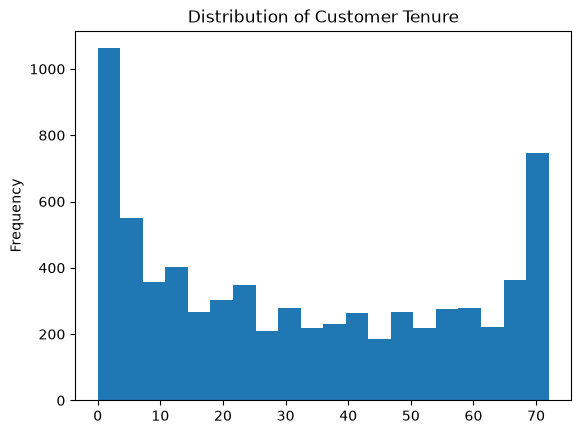

In [25]:
# Task 12 — numerical feature 1: distribution plot
df_clean["tenure"].plot(kind="hist", bins=20, title="Distribution of Customer Tenure")

**Observation:** _The tenure distribution ranges from 0 to about 72 months. There are many customers with very short tenure, while there is also a large group of customers with long tenure around 70 months. The distribution is not evenly spread across the tenure range._

<Axes: title={'center': 'Distribution of Monthly Charges'}, ylabel='Frequency'>

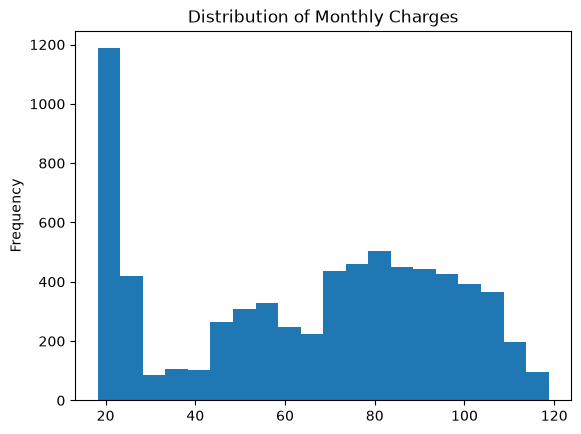

In [26]:
# Task 12 — numerical feature 2: distribution plot
df_clean["MonthlyCharges"].plot(kind="hist", bins=20, title="Distribution of Monthly Charges")

**Observation:** _This chart has uneven distribution. It ranges from 18 to 118. Highest frequency found at 18 to 27.Then we ave dip from 27 to 48. Then we have an smoother distribution afterward. This suggest we have two type of customers. one paying for a single basic service and another paying for bundled or higher tier services_

<Axes: title={'center': 'Distribution of Contract types'}, xlabel='Contract'>

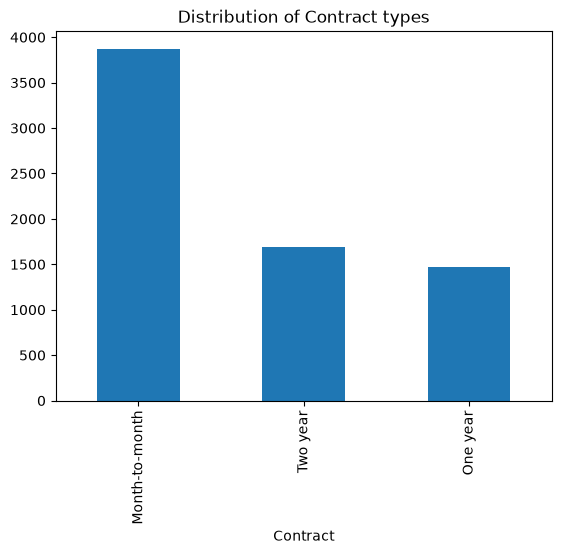

In [27]:
# Task 12 — categorical feature 1: distribution plot
df_clean["Contract"].value_counts().plot(kind="bar",title="Distribution of Contract types")

**Observation:** _Month-to-month at roughly 3900, two year around 1700, one year around 1470. This plot suggest that customers with month-to-month contract are highest in number. while one year and two year contract customers are almost same in number but with two-year a little more. This suggest that majority of customers are interested in monthly contract._

<Axes: title={'center': 'Distribution of Internet Service'}, xlabel='InternetService'>

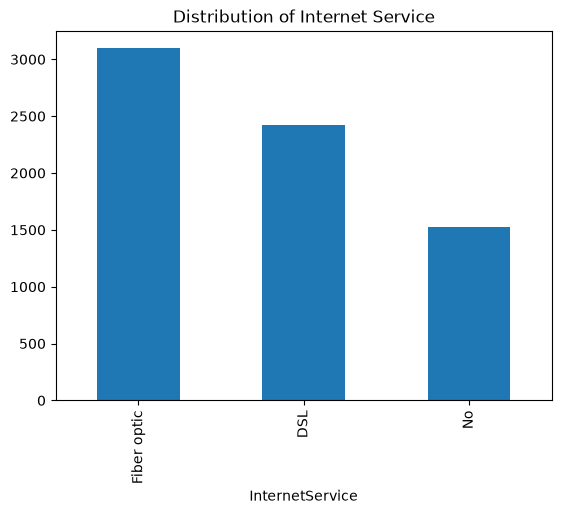

In [28]:
# Task 12 — categorical feature 2: distribution plot
df_clean["InternetService"].value_counts().plot(kind="bar", title="Distribution of Internet Service")

**Observation:** _This chart suggest that most customers go for fibre optic. and then for DSL internet service. while lower than fibre optic and DSL, but there is a great number(0-1500) which go for No Internet Service_

**Answer 13 (outliers / skew and possible explanation):**
_No real outliers here, meaning no broken or impossible values.. But tenure and MonthlyCharges both have two peaks instead of one. Tenure has lots of new customers and lots of old customers, not many in between. MonthlyCharges has lots of cheap customers and lots of expensive customers. This makes sense because most customers are on month-to-month plans, which are usually newer and cheaper, while fiber optic customers pay more. So it's not bad data, it's just two different types of customers mixed together._

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [16]:
# Task 14 — churn counts and percentages
print(df_clean["Churn"].value_counts())

print(df_clean["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_Imbalanced. 5174 customers didn't churn (about 73%) and 1869 did (about 27%). Not close to a 50-50 split, so the target is skewed toward "No"._

**Answer 15 (why imbalance might matter later):**
_Since most customers didn't churn, a model could just predict "No" for everyone and still get around 73% accuracy without learning anything useful. So accuracy alone can be misleading here, and the model might end up bad at catching the customers who actually do churn, which is the group we actually care about._

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [17]:
# Task 16 — categorical feature 1 vs Churn
pd.crosstab(df_clean["Contract"], df_clean["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**Observation:** _Churn rate drops sharply as contract length increases._

**Evidence:** _Month-to-month customers churn at about 43%, one year customers at about 11%, and two year customers at only about 3%._

**Possible Explanation:** _Month-to-month customers can leave anytime with no penalty, so it's easy for them to switch to a competitor. Longer contracts likely come with a commitment or discount that makes leaving less convenient, so those customers stick around more._

In [18]:
# Task 16 — categorical feature 2 vs Churn
pd.crosstab(df_clean["InternetService"], df_clean["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


**Observation:** _Fiber optic customers churn far more than DSL or no-internet customers._

**Evidence:** _Fiber optic churns at about 42%, DSL at about 19%, and customers with no internet service at only about 7%._

**Possible Explanation:** _Fiber optic is the priciest service tier, so those customers may be more price-sensitive or more likely to be lured by competitor deals. Customers with no internet service have less to be dissatisfied with in the first place, which lines up with their low churn rate._

<Axes: xlabel='Churn', ylabel='tenure'>

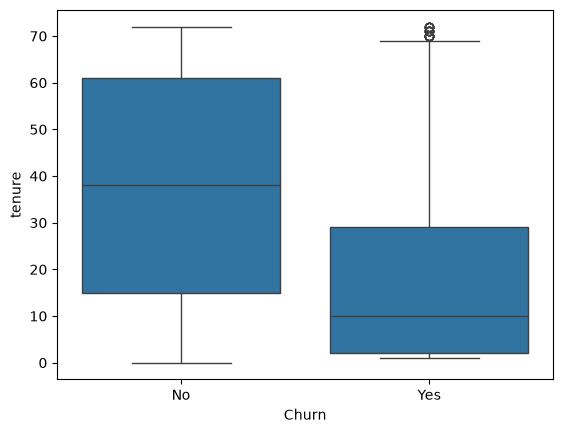

In [19]:
# Task 17 — numerical feature 1 vs Churn
sns.boxplot(x="Churn", y="tenure", data=df_clean)

**Observation:** _Customers who churned have much lower tenure than those who stayed._

**Evidence:** _The median tenure for non-churned customers is around 38 months, while churned customers have a median around 10 months._

**Possible Explanation:** _his matches the contract finding. Customers tend to leave earlier in their relationship with the company, likely before they've settled in or committed to a longer plan. Once someone stays past a certain point, they're less likely to leave._

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

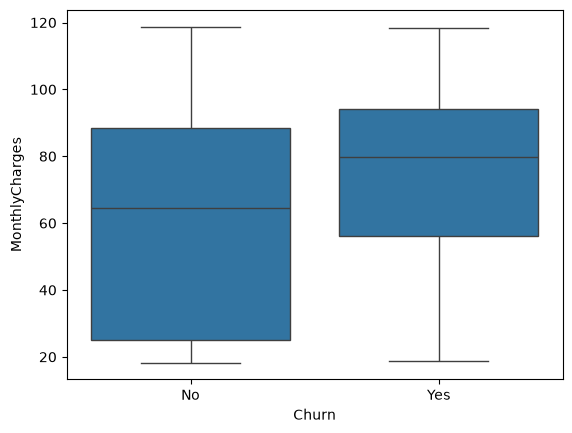

In [20]:
# Task 17 — numerical feature 2 vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_clean)

**Observation:** _Customers who churned tend to pay more per month than those who stayed._

**Evidence:** _The median MonthlyCharges for non-churned customers is around 65, while churned customers have a median around 80._

**Possible Explanation:** _This lines up with the fiber optic finding, since fiber is the pricier service and also the highest-churning group. Higher bills likely make customers more price-sensitive and more open to switching providers._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

<Axes: >

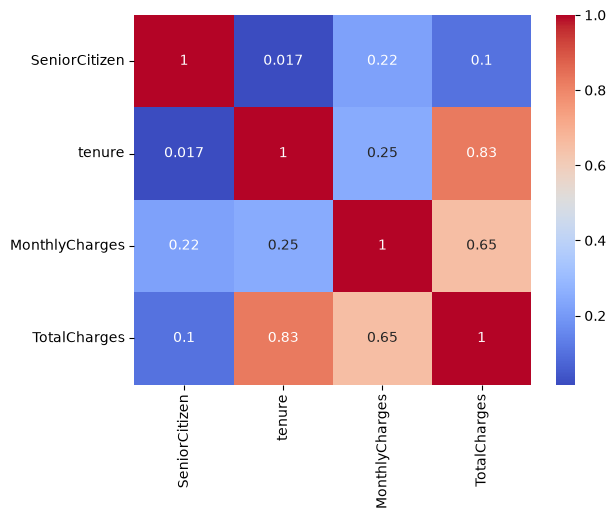

In [21]:
# Task 18 — correlation matrix and heatmap
corr_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

**Answer 18 (most correlated pairs):**
_Tenure and TotalCharges are the most correlated pair, at 0.83. MonthlyCharges and TotalCharges are also fairly correlated, at 0.65. SeniorCitizen barely correlates with anything._

**Answer 19 (correlation vs. causation; potential problems):**
_Correlation doesn't imply causation here. TotalCharges is high mainly because it's basically tenure multiplied by MonthlyCharges, longer-staying customers rack up more total billing, that's math, not a real-world cause. Since TotalCharges is so strongly tied to tenure, keeping both in a future model could be redundant and might make it harder to tell which one is actually driving predictions._

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_TotalCharges is one. It's basically tenure times MonthlyCharges, so it's kind of already telling us how long the customer stuck around, which is close to giving away the answer. customerID is another, but for a different reason, it's just an ID number with no real meaning, so it shouldn't be in the model at all._

**Answer 21 (what would go wrong):**
_If we kept TotalCharges, the model would sort of already know how long the customer stayed, so it would look way more accurate than it actually is, and it wouldn't work well on a brand new customer we don't have that info for yet. Keeping customerID would just confuse the model since it's not a real pattern, just a random ID._

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | 	Just an ID, no predictive value |
| tenure | Numerical | Feature | 	Keep  | 	Strongly tied to churn, showed clear difference |
| Contract | Categorical | Feature |Keep	|  Strongest churn link found in Part 7 |
| Churn | Categorical | Target | Keep |	This is what we're predicting |
| gender	| Categorical |	Feature	| Keep |	Demographic, may relate to churn |
|SeniorCitizen |	Categorical |	Feature |	Keep |	Already numeric (0/1), usable as is |
|Partner |	Categorical |	Feature	| Keep	| May affect stability/likelihood to churn |
|Dependents	| Categorical	| Feature	| Keep	|Same reasoning as Partner |
| PhoneService	| Categorical	| Feature	| Keep	| Service type customer subscribes to |
|MultipleLines	|Categorical	| Feature	| Keep	| Service detail, may relate to bundling behavior |
|InternetService	| Categorical	| Feature	| Keep	| Strong churn link shown in Part 7 |
|OnlineSecurity	| Categorical	| Feature	| Keep	| Add-on service, may reduce churn |
|OnlineBackup	| Categorical	| Feature	| Keep	| Add-on service, may reduce churn |
|DeviceProtection	| Categorical	| Feature	| Keep	| Add-on service, may reduce churn |
|TechSupport	| Categorical	| Feature	| Keep	| Add-on service, may reduce churn |
|StreamingTV	| Categorical	| Feature	| Keep	| Add-on service, minor churn signal |
|StreamingMovies	| Categorical	| Feature	| Keep	| Add-on service, minor churn sign |
|PaperlessBilling	| Categorical	| Feature	| Keep	| Billing preference, may relate to churn |
|PaymentMethod	| Categorical	| Feature	| Keep	| Billing preference, may relate to churn |
|MonthlyCharges	| Numerical	| Feature	| Keep	| Clear churn link shown in Part 7 |
|TotalCharges	| Numerical	| Feature	| Remove	| Data leakage risk, mostly encodes tenure |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [22]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...
clean_df["TotalCharges"] = clean_df["TotalCharges"].str.strip()
clean_df["TotalCharges"] = clean_df["TotalCharges"].replace("", pd.NA)
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"])
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)

#also removing identifier column, not a predictive feature
clean_df = clean_df.drop(columns=["customerID"])

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [23]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print(clean_df.info())
print("\nMissing values:")
print(clean_df.isnull().sum())
print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _Contract type is the strongest signal for churn_
- Evidence: _Month-to-month churns at 43%, one year at 11%, two year at only 3%._
- Interpretation: _People with no commitment leave way easier, so contract length really affects if someone stays._

**Finding 2**
- Observation: _New customers churn a lot more than old ones._
- Evidence: _Churned customers have a median tenure of 10 months, while ones who stayed have a median of 38 months._
- Interpretation: _People are most likely to leave early on, so the first few months matter the most for keeping them._

**Finding 3**
- Observation: _Fiber optic customers churn way more than DSL or no internet._
- Evidence: _Fiber optic churns at 42%, DSL at 19%, no internet at just 7%._
- Interpretation: _Probably because fiber costs more, so those customers are more likely to switch if they find a better deal._

**Finding 4**
- Observation: _The target column is imbalanced._
- Evidence: _73% didn't churn, only 27% did._
- Interpretation: _A model could just guess "No" every time and still look accurate, so we can't judge it on accuracy alone later._

**Finding 5**
- Observation: _TotalCharges basically repeats info we already have._
- Evidence: _It's correlated 0.83 with tenure and 0.65 with MonthlyCharges._
- Interpretation: _It's not really new information, it's more like tenure and charges combined, so it needs to be handled carefully so it doesn't leak info into the model._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _TotalCharges was stored as text and had 11 blank values, so it needed fixing before it could even be used as a number._
2. What was the most interesting pattern you discovered?
   _The two-peak pattern in tenure and MonthlyCharges, basically showed there's two kinds of customers, new/cheap ones and long-term/expensive ones._
3. Which feature seems most useful for predicting churn?
   _Contract type, it had the biggest and clearest difference in churn rate._
4. Which feature should probably not be used, and why?
   _TotalCharges, since it's mostly just tenure and MonthlyCharges combined, so it could leak info._
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _We'll need to convert categorical columns into numbers somehow, maybe scale the numerical ones, and deal with the class imbalance so the model doesn't just favor "No" every time._
6. What would you do next if you had another 3 hours?
   _I'd look more into PaymentMethod and try combining features together, like Contract with InternetService, to find which specific customer types are the riskiest._